In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías importadas correctamente. Entorno listo.")

✅ Librerías importadas correctamente. Entorno listo.


In [ ]:
print("--- 1. CARGA DE DATOS Y BÚSQUEDA DEL TOP 3 ---")
anios = range(2018, 2027)
df_list = []

for anio in anios:
    nombre_archivo = f"venta {anio}.xls"
    temp_df = None
    try:
        temp_df = pd.read_excel(nombre_archivo)
        print(f"✅ {nombre_archivo}: Cargado como Excel")
    except Exception:
        try:
            temp_df = pd.read_csv(nombre_archivo, encoding="latin-1", on_bad_lines='skip')
            print(f"✅ {nombre_archivo}: Cargado como CSV")
        except Exception:
            pass # Si falla, ignoramos y seguimos

    if temp_df is not None:
        df_list.append(temp_df)

data_completa = pd.concat(df_list, ignore_index=True)
data_completa['cantidad'] = data_completa['cantidad'] / 50

print("¡Datos cargados y convertidos a sacos exitosamente!")
print(f"\nTotal de filas en el historial: {len(data_completa)}")

# =====================================================================
# NUEVO: CARGAR Y PREPARAR VARIABLES EXÓGENAS
# =====================================================================
print("Cargando variables exógenas...")
df_exo = pd.read_excel("Variables exogenas final.xlsx")

# Convertimos la columna 'Mes/Año' a formato de fecha de Python
df_exo['Fecha'] = pd.to_datetime(df_exo['Mes/Año'])

# Extraemos el Año y el Mes para que sea súper fácil cruzarlo con nuestras ventas
df_exo['year'] = df_exo['Fecha'].dt.year
df_exo['month'] = df_exo['Fecha'].dt.month

# Nos quedamos solo con las columnas que nos importan
df_exo = df_exo[['year', 'month', 'Precio_Urea_MAG', 'Promedio_precipitaciones_Pichincha', 'Evento_Excepcion']]

print("¡Variables exógenas listas para integrarse!")

# Descubrir el TOP 3 de productos más vendidos
top_productos = data_completa.groupby('nomart')['cantidad'].sum().sort_values(ascending=False).head(3)

print("\n🏆 EL TOP 3 DE PRODUCTOS ESTRELLA ES:")
for i, (nombre, cantidad) in enumerate(top_productos.items(), 1):
    print(f"{i}. {nombre} ({cantidad:,.0f} sacos vendidos)")

# Guardar los nombres en una lista para el bucle
lista_top_3 = top_productos.index.tolist()

--- 1. CARGA DE DATOS Y BÚSQUEDA DEL TOP 3 ---
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
✅ venta 2018.xls: Cargado como Excel
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
✅ venta 2019.xls: Cargado como Excel
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
✅ venta 2020.xls: Cargado como Excel
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
✅ venta 2021.xls: Cargado como Excel
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
✅ venta 2022.xls: Cargado como Excel
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is


██████████████████████████████████████████████████████████████████████
🚀 INICIANDO ANÁLISIS Y ENTRENAMIENTO PARA:
   SULFATO DE CALCIO/YESO AGRICOLA 50 KG (NACIONAL)
   📈 ESTRATEGIA: Modelo Autoregresivo (SIN Variables Exógenas)
██████████████████████████████████████████████████████████████████████
Buscando hiperparámetros óptimos...
  ✓ Mejor configuración: {'learning_rate': 0.15, 'max_depth': 3, 'min_child_weight': 2, 'n_estimators': 300, 'subsample': 1.0}


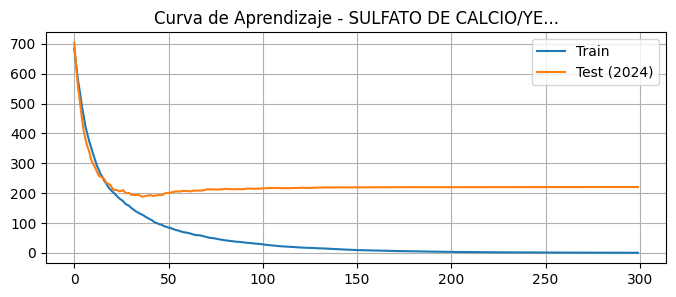


--- MÉTRICAS PARA ESTE PRODUCTO ---
Exactitud Predictiva (Acotada): 79.27%
Error Promedio (MAE):         173 sacos


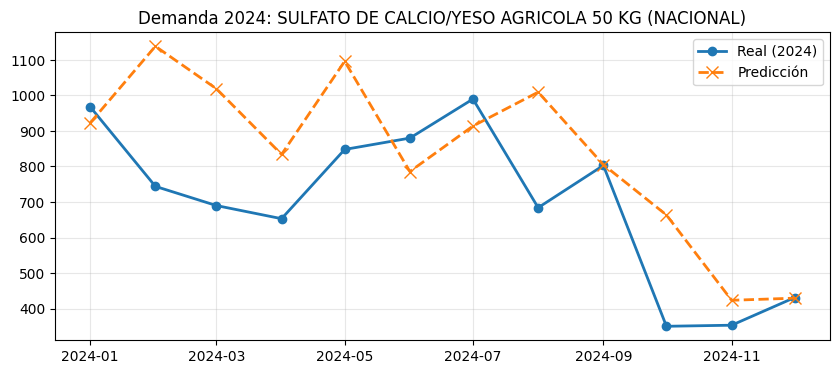

Generando análisis SHAP...


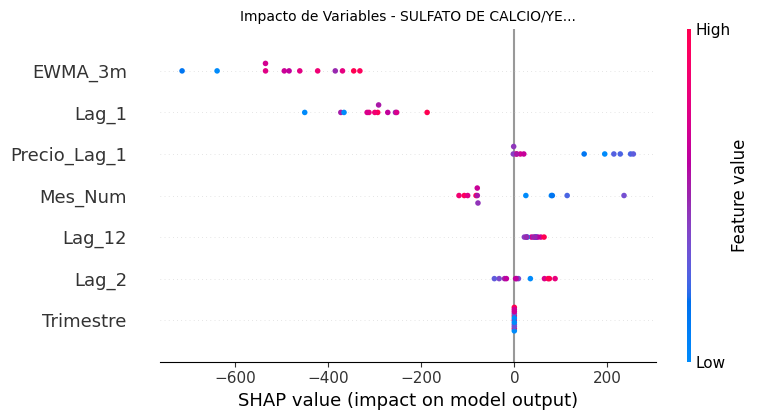

✅ Modelo guardado exitosamente.


██████████████████████████████████████████████████████████████████████
🚀 INICIANDO ANÁLISIS Y ENTRENAMIENTO PARA:
   CARBONATO DE CALCIO/CAL AGRICOLA 50 KG
   🧠 ESTRATEGIA: Modelo Causal (CON Variables Exógenas)
██████████████████████████████████████████████████████████████████████
Buscando hiperparámetros óptimos...
  ✓ Mejor configuración: {'learning_rate': 0.15, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.9}


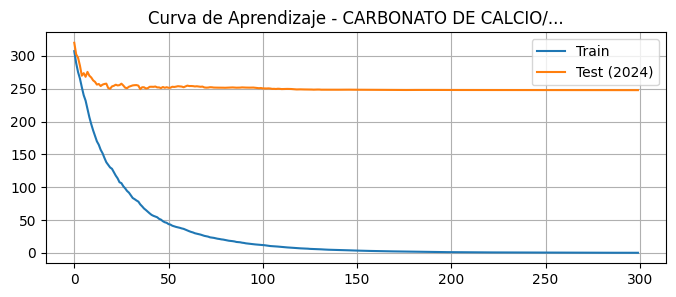


--- MÉTRICAS PARA ESTE PRODUCTO ---
Exactitud Predictiva (Acotada): 83.08%
Error Promedio (MAE):         200 sacos


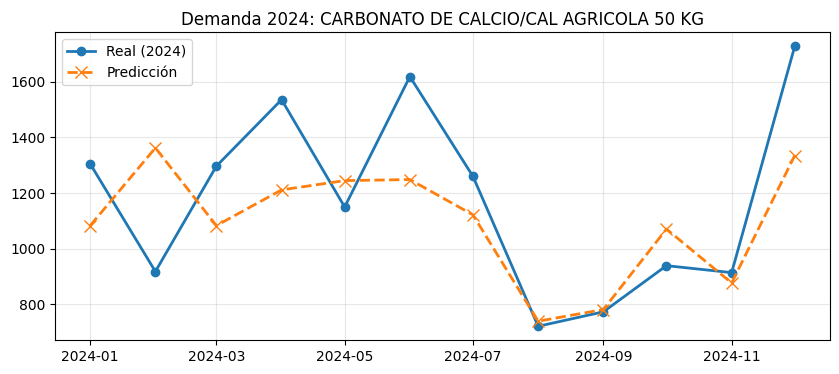

Generando análisis SHAP...


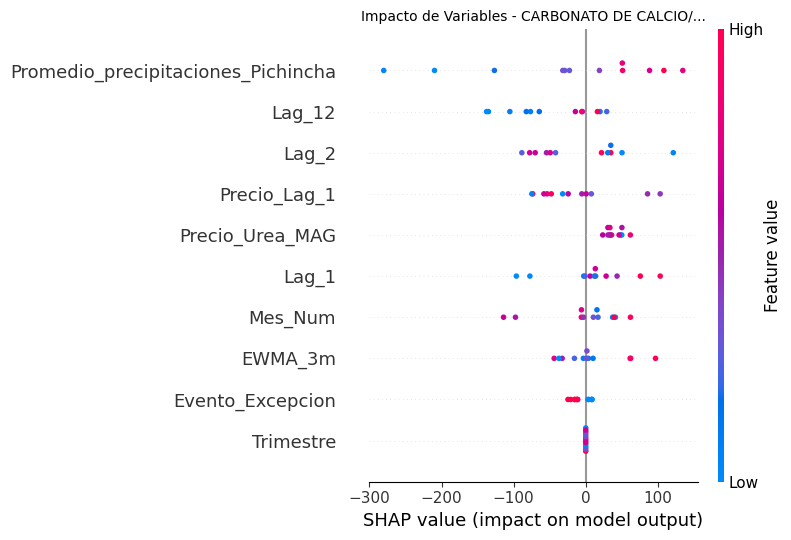

✅ Modelo guardado exitosamente.


██████████████████████████████████████████████████████████████████████
🚀 INICIANDO ANÁLISIS Y ENTRENAMIENTO PARA:
   CALDOLOMITA 50 KG (NACIONAL)
   📈 ESTRATEGIA: Modelo Autoregresivo (SIN Variables Exógenas)
██████████████████████████████████████████████████████████████████████
Buscando hiperparámetros óptimos...
  ✓ Mejor configuración: {'learning_rate': 0.15, 'max_depth': 3, 'min_child_weight': 2, 'n_estimators': 100, 'subsample': 0.8}


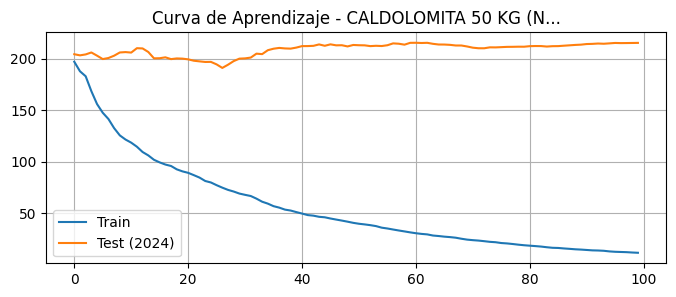


--- MÉTRICAS PARA ESTE PRODUCTO ---
Exactitud Predictiva (Acotada): 47.92%
Error Promedio (MAE):         166 sacos


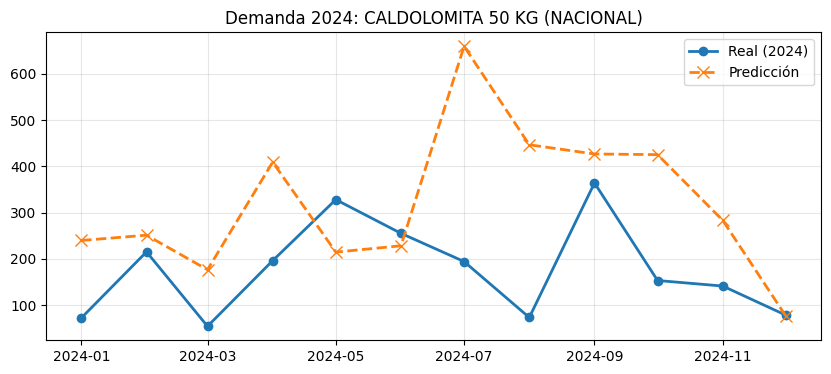

Generando análisis SHAP...


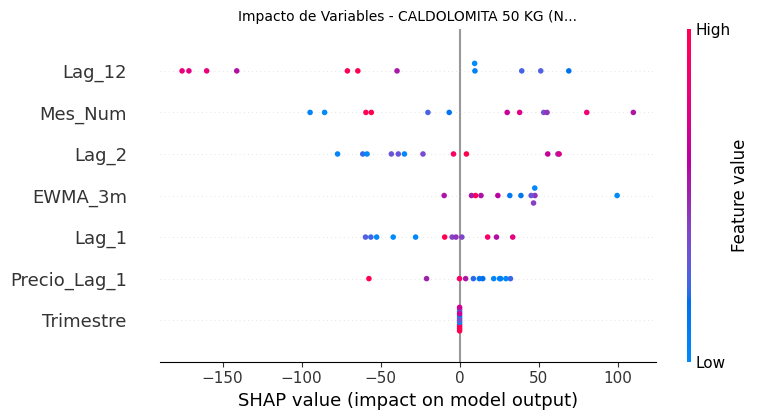

✅ Modelo guardado exitosamente.



In [ ]:
# Diccionario para guardar el resumen final
resultados_finales = {}

for producto in lista_top_3:
    print("\n" + "█"*70)
    print(f"🚀 INICIANDO ANÁLISIS Y ENTRENAMIENTO PARA:\n   {producto}")

    # =====================================================================
    # DETECCIÓN DE ESTRATEGIA (MODELADO HÍBRIDO)
    # =====================================================================
    usar_exogenas = True if "CALDOLOMITA" and "CARBONATO" in producto else False

    if usar_exogenas:
        print("   🧠 ESTRATEGIA: Modelo Causal (CON Variables Exógenas)")
    else:
        print("   📈 ESTRATEGIA: Modelo Autoregresivo (SIN Variables Exógenas)")
    print("█"*70)

    # 1. FILTRAR Y LIMPIAR FECHAS PARA ESTE PRODUCTO
    data_prod = data_completa[data_completa['nomart'] == producto].copy()

    def convertir_fecha(valor):
        if isinstance(valor, pd.Timestamp) or pd.api.types.is_datetime64_any_dtype(type(valor)):
            return valor
        try:
            return pd.to_datetime(float(valor), origin='1899-12-30', unit='D')
        except:
            return pd.to_datetime(valor, errors='coerce')

    data_prod['fecha_real'] = data_prod['emision'].apply(convertir_fecha)
    data_prod['fecha_real'] = pd.to_datetime(data_prod['fecha_real'])
    data_prod['Año'] = data_prod['fecha_real'].dt.year
    data_prod['Mes'] = data_prod['fecha_real'].dt.month

    demanda_mensual = data_prod.groupby(['Año', 'Mes']).agg(
        cantidad=('cantidad', 'sum'),
        precio_promedio=('precio', 'mean')
    ).reset_index()

    columnas_fecha = demanda_mensual[['Año', 'Mes']].rename(columns={'Año': 'year', 'Mes': 'month'})
    demanda_mensual['Fecha'] = pd.to_datetime(columnas_fecha.assign(day=1))
    demanda_mensual.sort_values('Fecha', inplace=True)

    # =====================================================================
    # AQUÍ VA EL PASO 2: INTEGRACIÓN DE VARIABLES EXÓGENAS
    # =====================================================================
    # Cruzamos las ventas con el clima, la urea y las excepciones
    demanda_mensual = pd.merge(demanda_mensual, df_exo, how='left', left_on=['Año', 'Mes'], right_on=['year', 'month'])

    # Restauramos la Fecha como índice principal
    demanda_mensual.set_index('Fecha', inplace=True)

    # Limpiamos columnas redundantes
    demanda_mensual.drop(['year', 'month', 'Año', 'Mes'], axis=1, inplace=True, errors='ignore')

    # Llenamos vacíos heredando el valor del mes anterior (por si algún Excel exógeno vino vacío)
    demanda_mensual.fillna(method='ffill', inplace=True)
    demanda_mensual.fillna(0, inplace=True) # Por si el primer registro absoluto es nulo

    # =====================================================================
    # 2. INGENIERÍA DE CARACTERÍSTICAS
    # =====================================================================
    demanda_mensual['Lag_1'] = demanda_mensual['cantidad'].shift(1)
    demanda_mensual['Lag_2'] = demanda_mensual['cantidad'].shift(2)
    demanda_mensual['Lag_12'] = demanda_mensual['cantidad'].shift(12)
    demanda_mensual['Precio_Lag_1'] = demanda_mensual['precio_promedio'].shift(1)
    demanda_mensual['EWMA_3m'] = demanda_mensual['cantidad'].ewm(span=3, adjust=False).mean().shift(1)
    demanda_mensual['Trimestre'] = demanda_mensual.index.quarter
    demanda_mensual['Mes_Num'] = demanda_mensual.index.month

    df_modelo = demanda_mensual.dropna().copy()

    # ¡ACTUALIZAMOS EL CEREBRO! (Modelado Híbrido)
    if usar_exogenas:
        features = [
            'Mes_Num', 'Trimestre', 'Lag_1', 'Lag_2', 'Lag_12', 'EWMA_3m', 'Precio_Lag_1',
            'Precio_Urea_MAG', 'Promedio_precipitaciones_Pichincha', 'Evento_Excepcion'
        ]
        xgb_base = xgb.XGBRegressor(random_state=42)
        param_grid = {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.05, 0.1, 0.15],
            'max_depth': [3, 4, 5],
            'min_child_weight': [1, 2],
            'subsample': [0.8, 0.9, 1.0]
        }
    else:
        features = ['Mes_Num', 'Trimestre', 'Lag_1', 'Lag_2', 'Lag_12', 'EWMA_3m', 'Precio_Lag_1']
        xgb_base = xgb.XGBRegressor(random_state=42)
        param_grid = {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.05, 0.1, 0.15],
            'max_depth': [3, 4, 5],
            'min_child_weight': [1, 2],
            'subsample': [0.8, 0.9, 1.0]
        }

    X = df_modelo[features]
    y = df_modelo['cantidad']

    # 3. DIVISIÓN TRAIN/TEST (Validación 2024)
    X_train = X[X.index.year < 2024]
    y_train = y[y.index.year < 2024]
    X_test = X[X.index.year == 2024]
    y_test = y[y.index.year == 2024]

    # 4. OPTIMIZACIÓN XGBOOST
    print("Buscando hiperparámetros óptimos...")
    tscv = TimeSeriesSplit(n_splits=3)

    grid_search = GridSearchCV(estimator=xgb_base, param_grid=param_grid, cv=tscv,
                               scoring='neg_root_mean_squared_error', verbose=0, n_jobs=-1)
    grid_search.fit(X_train, y_train)

    print(f"  ✓ Mejor configuración: {grid_search.best_params_}")

    xgb_model = grid_search.best_estimator_
    eval_set = [(X_train, y_train), (X_test, y_test)]
    xgb_model.fit(X_train, y_train, eval_set=eval_set, verbose=False)

    # GRÁFICO 1: Curva de Pérdida
    resultados = xgb_model.evals_result()
    x_axis = range(0, len(resultados['validation_0']['rmse']))
    plt.figure(figsize=(8, 3))
    plt.plot(x_axis, resultados['validation_0']['rmse'], label='Train')
    plt.plot(x_axis, resultados['validation_1']['rmse'], label='Test (2024)')
    plt.legend()
    plt.title(f'Curva de Aprendizaje - {producto[:20]}...')
    plt.grid(True)
    plt.show()

    # 5. PREDICCIÓN Y MÉTRICAS (Fórmula Acotada)
    y_pred = xgb_model.predict(X_test)
    y_pred = np.maximum(y_pred, 0)

    mae = mean_absolute_error(y_test, y_pred)

    suma_errores_absolutos = np.sum(np.abs(y_test - y_pred))
    suma_ventas_reales = np.sum(y_test)
    suma_predicciones = np.sum(y_pred)

    # FÓRMULA ACOTADA: Evita el 0% al dividir por el número mayor
    denominador = max(suma_ventas_reales, suma_predicciones)

    if denominador > 0:
        error_porcentual = (suma_errores_absolutos / denominador) * 100
    else:
        error_porcentual = 100.0

    exactitud = max(0, 100 - error_porcentual)
    resultados_finales[producto] = {'Exactitud': exactitud, 'MAE': mae}

    print(f"\n--- MÉTRICAS PARA ESTE PRODUCTO ---")
    print(f"Exactitud Predictiva (Acotada): {exactitud:.2f}%")
    print(f"Error Promedio (MAE):         {mae:,.0f} sacos")

    # GRÁFICO 2: Realidad vs Predicción
    plt.figure(figsize=(10, 4))
    plt.plot(y_test.index, y_test.values, marker='o', linewidth=2, label='Real (2024)', color='#1f77b4')
    plt.plot(y_test.index, y_pred, marker='x', markersize=8, linewidth=2, linestyle='--', label='Predicción', color='#ff7f0e')
    plt.title(f'Demanda 2024: {producto}', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # GRÁFICO 3: SHAP Values
    print("Generando análisis SHAP...")
    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_test)
    plt.figure(figsize=(8, 4))
    plt.title(f'Impacto de Variables - {producto[:20]}...', fontsize=10)
    shap.summary_plot(shap_values, X_test, feature_names=features, show=False)
    plt.show()

    # 6. GUARDAR MODELO
    nombre_limpio = "".join([c for c in producto if c.isalpha() or c.isdigit() or c==' ']).rstrip()
    joblib.dump(xgb_model, f'modelo_{nombre_limpio[:15]}.pkl')
    print(f"✅ Modelo guardado exitosamente.\n")

In [ ]:
print("=" * 60)
print("📊 RESUMEN EJECUTIVO: EXACTITUD DE MODELOS TOP 3")
print("=" * 60)

resumen_df = pd.DataFrame(resultados_finales).T
resumen_df = resumen_df.sort_values(by='Exactitud', ascending=False)

# Mostrar tabla formateada
for producto, datos in resumen_df.iterrows():
    print(f"Producto: {producto[:35]:<35} | Exactitud: {datos['Exactitud']:>5.2f}% | MAE: {datos['MAE']:>8,.0f} sacos")

print("=" * 60)
print("🎯 Todos los modelos han sido entrenados y guardados en el entorno.")

📊 RESUMEN EJECUTIVO: EXACTITUD DE MODELOS TOP 3
Producto: CARBONATO DE CALCIO/CAL AGRICOLA 50 | Exactitud: 83.08% | MAE:      200 sacos
Producto: SULFATO DE CALCIO/YESO AGRICOLA 50  | Exactitud: 79.27% | MAE:      173 sacos
Producto: CALDOLOMITA 50 KG (NACIONAL)        | Exactitud: 47.92% | MAE:      166 sacos
🎯 Todos los modelos han sido entrenados y guardados en el entorno.


**----- FASE 2: Puesta en Producción y Adaptabilidad Dinámica -----**

In [ ]:
print("=" * 60)
print("🚀 CAPÍTULO 2: PUESTA EN PRODUCCIÓN (PREDICCIÓN ENERO 2026)")
print("=" * 60)

for producto in lista_top_3:
    print(f"\nGenerando pronóstico oficial y buscando mejores hiperparámetros para: {producto}")

    # 1. Preparar datos para el producto
    data_prod = data_completa[data_completa['nomart'] == producto].copy()
    data_prod['fecha_real'] = data_prod['emision'].apply(convertir_fecha)
    data_prod['fecha_real'] = pd.to_datetime(data_prod['fecha_real'])
    data_prod['Año'] = data_prod['fecha_real'].dt.year
    data_prod['Mes'] = data_prod['fecha_real'].dt.month

    demanda_mensual = data_prod.groupby(['Año', 'Mes']).agg(
        cantidad=('cantidad', 'sum'),
        precio_promedio=('precio', 'mean')
    ).reset_index()

    columnas_fecha = demanda_mensual[['Año', 'Mes']].rename(columns={'Año': 'year', 'Mes': 'month'})
    demanda_mensual['Fecha'] = pd.to_datetime(columnas_fecha.assign(day=1))
    demanda_mensual.sort_values('Fecha', inplace=True)

    # =====================================================================
    # INTEGRACIÓN DE VARIABLES EXÓGENAS (Lluvia, Urea, Excepciones)
    # =====================================================================
    demanda_mensual = pd.merge(demanda_mensual, df_exo, how='left', left_on=['Año', 'Mes'], right_on=['year', 'month'])
    demanda_mensual.set_index('Fecha', inplace=True)
    demanda_mensual.drop(['year', 'month', 'Año', 'Mes'], axis=1, inplace=True, errors='ignore')

    # Llenamos vacíos heredando el valor del mes anterior
    demanda_mensual.fillna(method='ffill', inplace=True)
    demanda_mensual.fillna(0, inplace=True)

    # 2. Variables (Feature Engineering)
    demanda_mensual['Lag_1'] = demanda_mensual['cantidad'].shift(1)
    demanda_mensual['Lag_2'] = demanda_mensual['cantidad'].shift(2)
    demanda_mensual['Lag_12'] = demanda_mensual['cantidad'].shift(12)
    demanda_mensual['Precio_Lag_1'] = demanda_mensual['precio_promedio'].shift(1)
    demanda_mensual['EWMA_3m'] = demanda_mensual['cantidad'].ewm(span=3, adjust=False).mean().shift(1)
    demanda_mensual['Trimestre'] = demanda_mensual.index.quarter
    demanda_mensual['Mes_Num'] = demanda_mensual.index.month

    df_modelo = demanda_mensual.dropna().copy()

    # ¡CEREBRO ACTUALIZADO!
    features = [
        'Mes_Num', 'Trimestre', 'Lag_1', 'Lag_2', 'Lag_12', 'EWMA_3m', 'Precio_Lag_1',
        'Precio_Urea_MAG', 'Promedio_precipitaciones_Pichincha', 'Evento_Excepcion'
    ]

    X = df_modelo[features]
    y = df_modelo['cantidad']

    # 3. ENTRENAMIENTO CON TODA LA HISTORIA (2018 hasta Diciembre 2025)
    X_train_final = X[X.index.year <= 2025]
    y_train_final = y[y.index.year <= 2025]

    # El mes futuro que queremos predecir (Enero 2026)
    X_futuro = X[X.index.year == 2026]
    y_real_2026 = y[y.index.year == 2026]

    if len(X_futuro) == 0:
        print("⚠️ No se encontraron datos de 2026 para este producto.")
        continue

    # 4. BÚSQUEDA AUTOMÁTICA DE HIPERPARÁMETROS (GridSearchCV)
    tscv = TimeSeriesSplit(n_splits=3)

    # NUEVO: Frenos matemáticos activados para domar las 10 variables
    xgb_base = xgb.XGBRegressor(
        random_state=42
    )

    param_grid = {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.05, 0.1, 0.15],
        'max_depth': [3, 4, 5],
        'min_child_weight': [1, 2],
        'subsample': [0.8, 0.9, 1.0]
    }

    # Buscamos la mejor configuración usando solo la historia
    grid_search = GridSearchCV(
        estimator=xgb_base,
        param_grid=param_grid,
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        verbose=0,
        n_jobs=-1
    )

    grid_search.fit(X_train_final, y_train_final)
    print(f"  ✓ Mejor configuración hallada: {grid_search.best_params_}")

    # 5. ENTRENAMIENTO FINAL Y PREDICCIÓN
    # Usamos el mejor modelo encontrado y lo entrenamos con toda la data histórica
    xgb_final = grid_search.best_estimator_
    xgb_final.fit(X_train_final, y_train_final, verbose=False)

    prediccion_2026 = xgb_final.predict(X_futuro)
    prediccion_2026 = np.maximum(prediccion_2026, 0) # Evitar negativos

    # Extraer el valor del primer mes (Enero)
    venta_real = y_real_2026.iloc[0]
    venta_predicha = prediccion_2026[0]
    diferencia = abs(venta_real - venta_predicha)

    # Calcular el error en porcentaje para ese mes
    if venta_real > 0:
        error_porcentual = (diferencia / venta_real) * 100
    else:
        error_porcentual = 100.0

    print("-" * 50)
    print(f"Resultados Enero 2026:")
    print(f"  Venta REAL:        {venta_real:,.0f} sacos")
    print(f"  Predicción IA:     {venta_predicha:,.0f} sacos")
    print(f"  Desviación (MAE):  {diferencia:,.0f} sacos")
    print(f"  Exactitud del mes: {max(0, 100 - error_porcentual):.1f}%")
    print("-" * 50)

print("\n✅ ¡PRUEBA EN PRODUCCIÓN FINALIZADA!")

🚀 CAPÍTULO 2: PUESTA EN PRODUCCIÓN (PREDICCIÓN ENERO 2026)

Generando pronóstico oficial y buscando mejores hiperparámetros para: SULFATO DE CALCIO/YESO AGRICOLA 50 KG (NACIONAL)
  ✓ Mejor configuración hallada: {'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 2, 'n_estimators': 100, 'subsample': 1.0}
--------------------------------------------------
Resultados Enero 2026:
  Venta REAL:        1,265 sacos
  Predicción IA:     597 sacos
  Desviación (MAE):  668 sacos
  Exactitud del mes: 47.2%
--------------------------------------------------

Generando pronóstico oficial y buscando mejores hiperparámetros para: CARBONATO DE CALCIO/CAL AGRICOLA 50 KG
  ✓ Mejor configuración hallada: {'learning_rate': 0.15, 'max_depth': 3, 'min_child_weight': 2, 'n_estimators': 100, 'subsample': 0.9}
--------------------------------------------------
Resultados Enero 2026:
  Venta REAL:        1,843 sacos
  Predicción IA:     1,526 sacos
  Desviación (MAE):  317 sacos
  Exactitud del mes: 82

**----- FASE 3: El Plan Maestro de Demanda -----**

🔮 CAPÍTULO 3: EL FUTURO (PROYECCIÓN COMPLETA 2026 CON EXÓGENAS)

Buscando hiperparámetros y generando proyección anual 2026 para:
  SULFATO DE CALCIO/YESO AGRICOLA 50 KG (NACIONAL)
  ✓ Auto-Tuning completado: {'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 2, 'n_estimators': 100, 'subsample': 1.0}

--- Pronóstico Mes a Mes (2026) ---
  Ene 2026:      759 sacos
  Feb 2026:      786 sacos
  Mar 2026:      826 sacos
  Abr 2026:      914 sacos
  May 2026:      816 sacos
  Jun 2026:      782 sacos
  Jul 2026:      806 sacos
  Ago 2026:      631 sacos
  Sep 2026:      539 sacos
  Oct 2026:      696 sacos
  Nov 2026:      717 sacos
  Dic 2026:      670 sacos
-----------------------------------
  TOTAL ESPERADO 2026: 8,943 sacos


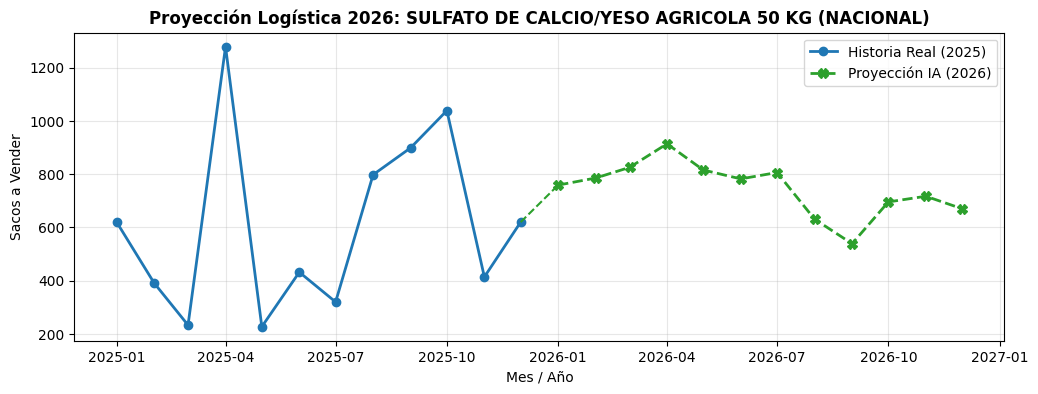


Buscando hiperparámetros y generando proyección anual 2026 para:
  CARBONATO DE CALCIO/CAL AGRICOLA 50 KG
  ✓ Auto-Tuning completado: {'learning_rate': 0.15, 'max_depth': 3, 'min_child_weight': 2, 'n_estimators': 100, 'subsample': 0.9}

--- Pronóstico Mes a Mes (2026) ---
  Ene 2026:    1,595 sacos
  Feb 2026:    1,251 sacos
  Mar 2026:    1,274 sacos
  Abr 2026:    1,027 sacos
  May 2026:      870 sacos
  Jun 2026:    1,068 sacos
  Jul 2026:    1,102 sacos
  Ago 2026:      529 sacos
  Sep 2026:    1,168 sacos
  Oct 2026:    1,394 sacos
  Nov 2026:    1,182 sacos
  Dic 2026:    1,437 sacos
-----------------------------------
  TOTAL ESPERADO 2026: 13,896 sacos


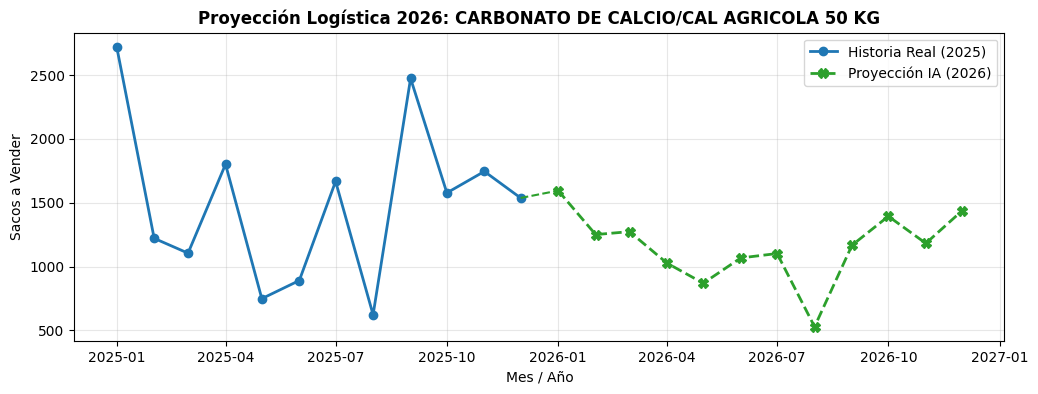


Buscando hiperparámetros y generando proyección anual 2026 para:
  CALDOLOMITA 50 KG (NACIONAL)
  ✓ Auto-Tuning completado: {'learning_rate': 0.15, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 0.9}

--- Pronóstico Mes a Mes (2026) ---
  Ene 2026:      256 sacos
  Feb 2026:      197 sacos
  Mar 2026:      308 sacos
  Abr 2026:      490 sacos
  May 2026:      418 sacos
  Jun 2026:      618 sacos
  Jul 2026:      425 sacos
  Ago 2026:      554 sacos
  Sep 2026:      239 sacos
  Oct 2026:      434 sacos
  Nov 2026:      334 sacos
  Dic 2026:      248 sacos
-----------------------------------
  TOTAL ESPERADO 2026: 4,522 sacos


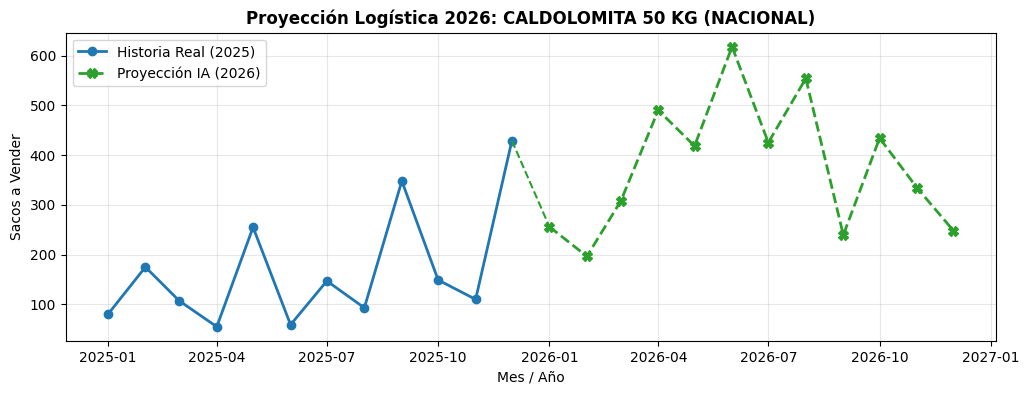

In [ ]:
print("=" * 60)
print("🔮 CAPÍTULO 3: EL FUTURO (PROYECCIÓN COMPLETA 2026 CON EXÓGENAS)")
print("=" * 60)

# Pre-calculamos los promedios históricos de lluvia por cada mes (del 1 al 12)
# Esto servirá para "adivinar" el clima de 2026
promedios_lluvia = df_exo.groupby('month')['Promedio_precipitaciones_Pichincha'].mean().to_dict()

for producto in lista_top_3:
    print(f"\nBuscando hiperparámetros y generando proyección anual 2026 para:\n  {producto}")

    # 1. Preparar datos históricos estrictamente hasta 2025
    data_prod = data_completa[data_completa['nomart'] == producto].copy()
    data_prod['fecha_real'] = data_prod['emision'].apply(convertir_fecha)
    data_prod['fecha_real'] = pd.to_datetime(data_prod['fecha_real'])
    data_prod['Año'] = data_prod['fecha_real'].dt.year
    data_prod['Mes'] = data_prod['fecha_real'].dt.month

    # Filtramos solo hasta 2025 para el entrenamiento puro
    data_prod = data_prod[data_prod['Año'] <= 2025]

    demanda_mensual = data_prod.groupby(['Año', 'Mes']).agg(
        cantidad=('cantidad', 'sum'),
        precio_promedio=('precio', 'mean')
    ).reset_index()

    columnas_fecha = demanda_mensual[['Año', 'Mes']].rename(columns={'Año': 'year', 'Mes': 'month'})
    demanda_mensual['Fecha'] = pd.to_datetime(columnas_fecha.assign(day=1))
    demanda_mensual.sort_values('Fecha', inplace=True)

    # =====================================================================
    # INTEGRACIÓN DE VARIABLES EXÓGENAS EN LA HISTORIA
    # =====================================================================
    demanda_mensual = pd.merge(demanda_mensual, df_exo, how='left', left_on=['Año', 'Mes'], right_on=['year', 'month'])
    demanda_mensual.set_index('Fecha', inplace=True)
    demanda_mensual.drop(['year', 'month', 'Año', 'Mes'], axis=1, inplace=True, errors='ignore')

    demanda_mensual.fillna(method='ffill', inplace=True)
    demanda_mensual.fillna(0, inplace=True)

    # 2. Variables (Feature Engineering)
    df_train = demanda_mensual.copy()
    df_train['Lag_1'] = df_train['cantidad'].shift(1)
    df_train['Lag_2'] = df_train['cantidad'].shift(2)
    df_train['Lag_12'] = df_train['cantidad'].shift(12)
    df_train['Precio_Lag_1'] = df_train['precio_promedio'].shift(1)
    df_train['EWMA_3m'] = df_train['cantidad'].ewm(span=3, adjust=False).mean().shift(1)
    df_train['Trimestre'] = df_train.index.quarter
    df_train['Mes_Num'] = df_train.index.month

    df_modelo = df_train.dropna().copy()

    # ¡CEREBRO ACTUALIZADO CON EXÓGENAS!
    features = [
        'Mes_Num', 'Trimestre', 'Lag_1', 'Lag_2', 'Lag_12', 'EWMA_3m', 'Precio_Lag_1',
        'Precio_Urea_MAG', 'Promedio_precipitaciones_Pichincha', 'Evento_Excepcion'
    ]

    X_train = df_modelo[features]
    y_train = df_modelo['cantidad']

    # 3. BÚSQUEDA AUTOMÁTICA DE HIPERPARÁMETROS (GridSearchCV)

    tscv = TimeSeriesSplit(n_splits=3)

    # NUEVO: Frenos matemáticos activados para domar las 10 variables
    xgb_base = xgb.XGBRegressor(
        random_state=42
    )

    param_grid = {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.05, 0.1, 0.15],
        'max_depth': [3, 4, 5],
        'min_child_weight': [1, 2],
        'subsample': [0.8, 0.9, 1.0]
    }

    # Buscamos la mejor configuración usando solo la historia
    grid_search = GridSearchCV(
        estimator=xgb_base,
        param_grid=param_grid,
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        verbose=0,
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)
    print(f"  ✓ Auto-Tuning completado: {grid_search.best_params_}")

    xgb_final = grid_search.best_estimator_
    xgb_final.fit(X_train, y_train)

    # =====================================================================
    # 4. PREDICCIÓN ITERATIVA MES A MES PARA 2026 (Con Asunciones de Futuro)
    # =====================================================================
    df_proyeccion = demanda_mensual.copy()

    # Extraemos los últimos valores conocidos para mantenerlos constantes en el futuro
    ultimo_precio_producto = df_proyeccion['precio_promedio'].iloc[-1]
    ultimo_precio_urea = df_proyeccion['Precio_Urea_MAG'].iloc[-1]

    predicciones_2026 = []
    fechas_2026 = pd.date_range(start='2026-01-01', end='2026-12-01', freq='MS')

    for fecha_futura in fechas_2026:
        mes_futuro = fecha_futura.month

        # Simulamos el clima histórico para ese mes específico
        lluvia_estimada = promedios_lluvia.get(mes_futuro, 0)

        # Añadir fila vacía para el mes que vamos a adivinar, INYECTANDO EXÓGENAS
        nueva_fila = pd.DataFrame({
            'cantidad': [np.nan],
            'precio_promedio': [ultimo_precio_producto],
            'Precio_Urea_MAG': [ultimo_precio_urea],                  # Asumimos que la urea no sube
            'Promedio_precipitaciones_Pichincha': [lluvia_estimada],  # Clima histórico promedio
            'Evento_Excepcion': [0]                                   # Asumimos que no habrá paros
        }, index=[fecha_futura])

        df_proyeccion = pd.concat([df_proyeccion, nueva_fila])

        # Recalcular variables matemáticas con la nueva historia
        df_proyeccion['Lag_1'] = df_proyeccion['cantidad'].shift(1)
        df_proyeccion['Lag_2'] = df_proyeccion['cantidad'].shift(2)
        df_proyeccion['Lag_12'] = df_proyeccion['cantidad'].shift(12)
        df_proyeccion['Precio_Lag_1'] = df_proyeccion['precio_promedio'].shift(1)
        df_proyeccion['EWMA_3m'] = df_proyeccion['cantidad'].ewm(span=3, adjust=False).mean().shift(1)
        df_proyeccion['Trimestre'] = df_proyeccion.index.quarter
        df_proyeccion['Mes_Num'] = df_proyeccion.index.month

        # Extraer las variables de esa fila futura
        X_mes_actual = df_proyeccion.loc[[fecha_futura], features]

        # Predecir
        pred = xgb_final.predict(X_mes_actual)[0]
        pred = max(0, pred)

        # Guardar predicción y rellenar el DataFrame para el siguiente ciclo
        predicciones_2026.append(pred)
        df_proyeccion.loc[fecha_futura, 'cantidad'] = pred

    # 5. MOSTRAR RESULTADOS
    print(f"\n--- Pronóstico Mes a Mes (2026) ---")
    meses_nombres = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
    for mes_nom, pred_val in zip(meses_nombres, predicciones_2026):
        print(f"  {mes_nom} 2026: {pred_val:>8,.0f} sacos")
    print("-" * 35)
    print(f"  TOTAL ESPERADO 2026: {sum(predicciones_2026):,.0f} sacos")

    # 6. GRÁFICA: Unir Realidad (2025) con Proyección (2026)
    historia_2025 = demanda_mensual[demanda_mensual.index.year == 2025]['cantidad']
    serie_2026 = pd.Series(predicciones_2026, index=fechas_2026)

    plt.figure(figsize=(12, 4))
    plt.plot(historia_2025.index, historia_2025.values, marker='o', label='Historia Real (2025)', color='#1f77b4', linewidth=2)
    plt.plot(serie_2026.index, serie_2026.values, marker='X', linestyle='--', label='Proyección IA (2026)', color='#2ca02c', linewidth=2, markersize=7)

    # Conectar visualmente diciembre 2025 con enero 2026
    plt.plot([historia_2025.index[-1], serie_2026.index[0]], [historia_2025.values[-1], serie_2026.values[0]], color='#2ca02c', linestyle='--')

    plt.title(f'Proyección Logística 2026: {producto}', fontsize=12, fontweight='bold')
    plt.xlabel('Mes / Año')
    plt.ylabel('Sacos a Vender')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()